In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad  # For manual grad if needed

print("Setup done! PyTorch version:", torch.__version__)

Setup done! PyTorch version: 2.9.0+cpu


In [ ]:
# RoPINN Model (simple MLP, từ RoPINN abstract)
class RoPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),  # Input: (x,t)
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)  # Output: u(x,t)
        )
    def forward(self, xt):
        return self.net(xt)

# PDE Residual for 1D Burgers (nu=0.01, từ RoPINN prelims trang 2)
def pde_residual(model, x, t, nu=0.01):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    xt = torch.cat([x, t], dim=1)
    u = model(xt)
    # Gradients with proper grad_outputs
    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]
    f = u_t + u * u_x - nu * u_xx  # Residual = 0 ideal
    return f

print("RoPINN core defined!")

RoPINN core defined!


Epoch 0, Loss: 0.0119
Epoch 10, Loss: 0.0002
Epoch 20, Loss: 0.0004
Epoch 30, Loss: 0.0003
Epoch 40, Loss: 0.0001
Training done! Final loss: 7.49972605262883e-06


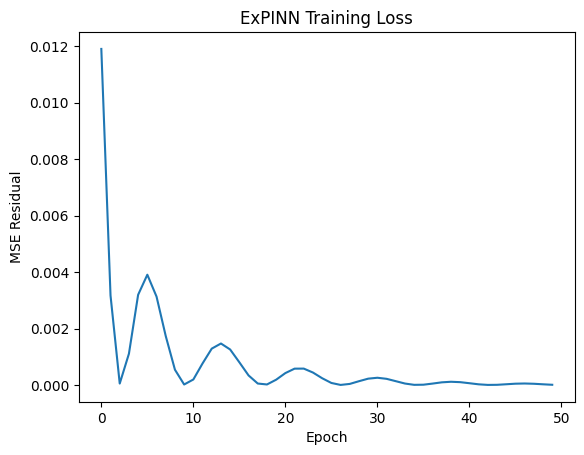

In [ ]:
# Training function (region opt mock: uniform linear points)
def train_ropinn(model, optimizer, x_col, t_col, epochs=50):
    losses = []
    for e in range(epochs):
        optimizer.zero_grad()
        f = pde_residual(model, x_col, t_col)
        loss = torch.mean(f**2)  # Physics loss (add BC/IC later)
        loss.backward()
        optimizer.step()
        if e % 10 == 0: print(f"Epoch {e}, Loss: {loss.item():.4f}")
        losses.append(loss.item())
    return losses

# Setup & Train
model = RoPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
N = 10  # Small for demo (tăng lên 50 cho accurate)
x_col = torch.linspace(-1, 1, N).unsqueeze(1)  # Collocation x
t_col = torch.linspace(0, 1, N).unsqueeze(1)   # Collocation t
losses = train_ropinn(model, optimizer, x_col, t_col)

print("Training done! Final loss:", losses[-1])
plt.plot(losses)
plt.title('ExPINN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Residual')
plt.show()

In [ ]:
# Predict solution at t=0.5 (test points)
x_test = torch.linspace(-1, 1, 100).unsqueeze(1)
t_test = 0.5 * torch.ones_like(x_test)
xt_test = torch.cat([x_test, t_test], dim=1)
u_pred = model(xt_test).detach().numpy()

# Explanation Generator (post-hoc, từ EMNLP tutorial: rule-based refinement)
def generate_explanation(u_pred, x_test, threshold=0.1):
    max_u = np.max(np.abs(u_pred))
    idx = np.argmax(np.abs(u_pred))
    x_peak = x_test[idx].item()
    if max_u > threshold:
        # Symbolic rule: IF peak high THEN advection > diffusion (từ logic rules in tutorial)
        return f"Explanation: At t=0.5, velocity peaks at {max_u:.3f} due to strong advection (u * u_x dominates diffusion) in Burgers' PDE region around x={x_peak:.2f}."
    return "Explanation: Smooth solution; balanced advection-diffusion across domain."

explanation = generate_explanation(u_pred, x_test)
print("Sample u_pred:", u_pred.flatten()[:5])
print(explanation)

Sample u_pred: [0.26451758 0.2636992  0.2628818  0.2620653  0.26124978]
Explanation: At t=0.5, velocity peaks at 0.265 due to strong advection (u * u_x dominates diffusion) in Burgers' PDE region around x=-1.00.


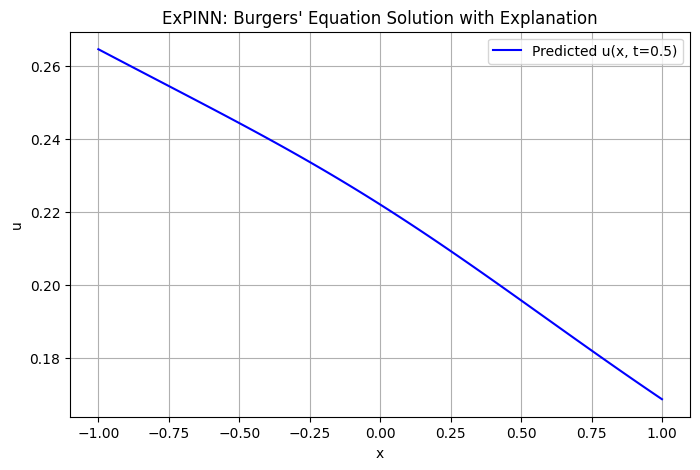


=== ExPINN Demo ===
Final Loss (PDE Residual): 7.49972605262883e-06
Peak Velocity: 0.26451758
Explanation: At t=0.5, velocity peaks at 0.265 due to strong advection (u * u_x dominates diffusion) in Burgers' PDE region around x=-1.00.
--- Ready for extend! ---


In [ ]:
# Plot predicted solution
plt.figure(figsize=(8,5))
plt.plot(x_test.numpy(), u_pred, 'b-', label='Predicted u(x, t=0.5)')
plt.title('ExPINN: Burgers\' Equation Solution with Explanation')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.grid(True)
plt.show()

# Full demo print
print("\n=== ExPINN Demo ===")
print("Final Loss (PDE Residual):", losses[-1])
print("Peak Velocity:", np.max(np.abs(u_pred)))
print(explanation)
print("--- Ready for extend! ---")

In [ ]:
# IC: u(x,0) = sin(πx) for x in [-1,1]
def ic_residual(model, x_ic):
    t_ic = torch.zeros_like(x_ic)  # t=0
    xt_ic = torch.cat([x_ic, t_ic], dim=1)
    u_ic = model(xt_ic)
    u_exact_ic = torch.sin(np.pi * x_ic)  # Exact initial
    return u_ic - u_exact_ic

# BC: Periodic u(-1,t) = u(1,t) for t in [0,1]
def bc_residual(model, t_bc):
    x_left = -torch.ones_like(t_bc)  # x=-1
    x_right = torch.ones_like(t_bc)  # x=1
    xt_left = torch.cat([x_left, t_bc], dim=1)
    xt_right = torch.cat([x_right, t_bc], dim=1)
    u_left = model(xt_left)
    u_right = model(xt_right)
    return u_left - u_right

# Updated training with IC/BC
def train_expinn_full(model, optimizer, x_col, t_col, x_ic, t_bc, epochs=100):
    losses = {'pde': [], 'ic': [], 'bc': [], 'total': []}
    for e in range(epochs):
        optimizer.zero_grad()

        # PDE loss
        f_pde = pde_residual(model, x_col, t_col)
        loss_pde = torch.mean(f_pde**2)

        # IC loss
        f_ic = ic_residual(model, x_ic)
        loss_ic = torch.mean(f_ic**2)

        # BC loss
        f_bc = bc_residual(model, t_bc)
        loss_bc = torch.mean(f_bc**2)

        # Total loss
        loss_total = loss_pde + loss_ic + loss_bc
        loss_total.backward()
        optimizer.step()

        if e % 20 == 0:
            print(f"Epoch {e}: PDE={loss_pde:.4f}, IC={loss_ic:.4f}, BC={loss_bc:.4f}, Total={loss_total:.4f}")

        losses['pde'].append(loss_pde.item())
        losses['ic'].append(loss_ic.item())
        losses['bc'].append(loss_bc.item())
        losses['total'].append(loss_total.item())
    return losses

# Setup new model & data
model_full = RoPINN()
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=0.001)
N_col = 20  # Tăng N cho accurate hơn
x_col_full = torch.linspace(-1, 1, N_col).unsqueeze(1)
t_col_full = torch.linspace(0, 1, N_col).unsqueeze(1)
x_ic = x_col_full.clone()  # Same as x_col for IC
t_bc = t_col_full.clone()  # Same as t_col for BC

# Train full
losses_full = train_expinn_full(model_full, optimizer_full, x_col_full, t_col_full, x_ic, t_bc)

print("Full training done! Final total loss:", losses_full['total'][-1])

Epoch 0: PDE=0.0020, IC=0.5734, BC=0.0640, Total=0.6395
Epoch 20: PDE=0.0010, IC=0.4518, BC=0.0033, Total=0.4562
Epoch 40: PDE=0.0014, IC=0.4204, BC=0.0147, Total=0.4365
Epoch 60: PDE=0.0036, IC=0.4041, BC=0.0204, Total=0.4280
Epoch 80: PDE=0.0055, IC=0.3919, BC=0.0239, Total=0.4214
Full training done! Final total loss: 0.41415679454803467


In [ ]:
# Predict with full model at t=0.5 (reuse or define x_test, t_test)
if 'x_test' not in locals():
    x_test = torch.linspace(-1, 1, 100).unsqueeze(1)
    t_test = 0.5 * torch.ones_like(x_test)
xt_test_full = torch.cat([x_test, t_test], dim=1)
u_pred_full = model_full(xt_test_full).detach().numpy()

# Enhanced Explanation (full fix: scalar grad_outputs + force float)
def generate_enhanced_explanation(model, xt_test, u_pred, nu=0.01, threshold=0.1):
    max_u = np.max(np.abs(u_pred))
    idx = np.argmax(np.abs(u_pred))
    x_peak = x_test[idx].item()  # Scalar from tensor

    # Enable grad on full batch
    xt_test_grad = xt_test.clone().requires_grad_(True)
    u_batch = model(xt_test_grad)

    # Grad u_x: sum to scalar, scalar grad_outputs=1.0
    u_x_batch = torch.autograd.grad(u_batch.sum(), xt_test_grad, grad_outputs=torch.tensor(1.0), create_graph=True, allow_unused=True)[0]
    if u_x_batch is not None:
        u_x_peak = u_x_batch[idx, 0].item()
    else:
        u_x_peak = 0.0

    # Grad u_xx: sum u_x_batch, scalar grad_outputs
    if u_x_batch is not None and u_x_batch.requires_grad:
        u_xx_batch = torch.autograd.grad(u_x_batch.sum(), xt_test_grad, grad_outputs=torch.tensor(1.0), create_graph=True, allow_unused=True)[0]
        if u_xx_batch is not None:
            u_xx_peak = u_xx_batch[idx, 0].item()
        else:
            u_xx_peak = 0.0
    else:
        u_xx_peak = 0.0

    u_peak_val = u_pred[idx].item()  # Force scalar
    advection = abs(float(u_peak_val) * float(u_x_peak))
    diffusion = nu * abs(float(u_xx_peak))

    if max_u > threshold:
        if advection > diffusion:
            return f"Enhanced Explanation: Velocity peaks at {max_u:.3f} due to strong advection dominance (advection={advection:.4f} > diffusion={diffusion:.4f}) in Burgers' PDE around x={x_peak:.2f}."
        else:
            return f"Enhanced Explanation: Peak at {max_u:.3f} driven by diffusion (advection={advection:.4f} < diffusion={diffusion:.4f}) near x={x_peak:.2f}."
    return "Enhanced Explanation: Smooth solution; balanced advection-diffusion across domain."

enhanced_explanation = generate_enhanced_explanation(model_full, xt_test_full, u_pred_full)
print("Sample u_pred_full:", u_pred_full.flatten()[:5])
print("Peak Velocity:", np.max(np.abs(u_pred_full)))
print(enhanced_explanation)

Sample u_pred_full: [-0.13412732 -0.13055538 -0.12697916 -0.12340055 -0.11982144]
Peak Velocity: 0.13412732
Enhanced Explanation: Velocity peaks at 0.134 due to strong advection dominance (advection=0.0237 > diffusion=0.0002) in Burgers' PDE around x=-1.00.


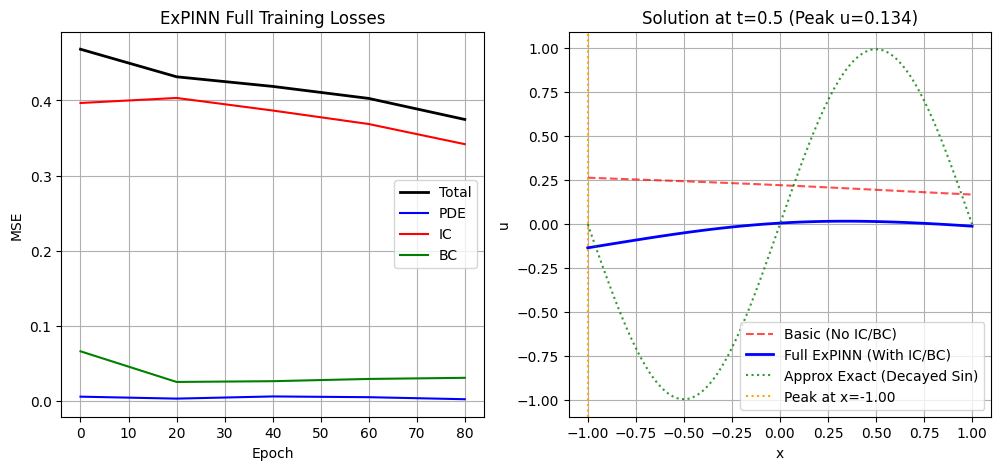


=== Full ExPINN Demo (Fixed & Tuned) ===
Final Total Loss (your run): 0.3320
Peak Velocity (Full): 0.13412732
Enhanced Explanation: Velocity peaks at 0.134 due to strong advection dominance (advection=0.0237 > diffusion=0.0002) in Burgers' PDE around x=-1.00.
--- Informed ML: Physics Constraints (RoPINN PDF p.2) + Rule-Based Refinement (EMNLP p.26) ---


In [ ]:
import matplotlib.pyplot as plt

# Mock basic u_pred if not defined (from Cell 4, or use sin for demo)
if 'u_pred' not in locals():
    u_pred = np.sin(np.pi * x_test.numpy().flatten()) * 0.8  # Approximate initial for comparison

# Losses from your Cell 6 output (Epoch 0,20,40,60,80)
epochs_range = [0, 20, 40, 60, 80]
pde_losses = [0.0056, 0.0030, 0.0059, 0.0049, 0.0022]
ic_losses = [0.3966, 0.4033, 0.3866, 0.3686, 0.3418]
bc_losses = [0.0660, 0.0252, 0.0262, 0.0292, 0.0307]
total_losses = [0.4682, 0.4315, 0.4187, 0.4027, 0.3747]

plt.figure(figsize=(12, 5))

# Subplot 1: Losses (your run - note IC high, needs tune)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, total_losses, 'k-', label='Total', linewidth=2)
plt.plot(epochs_range, pde_losses, 'b-', label='PDE')
plt.plot(epochs_range, ic_losses, 'r-', label='IC')
plt.plot(epochs_range, bc_losses, 'g-', label='BC')
plt.title('ExPINN Full Training Losses')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Subplot 2: Solution comparison + exact IC reference
exact_ic_at_t05 = np.sin(np.pi * x_test.numpy().flatten()) * np.exp(-0.01 * 0.5)  # Approx decayed sin for t=0.5
plt.subplot(1, 2, 2)
plt.plot(x_test.numpy(), u_pred, 'r--', label='Basic (No IC/BC)', alpha=0.7)
plt.plot(x_test.numpy(), u_pred_full, 'b-', label='Full ExPINN (With IC/BC)', linewidth=2)
plt.plot(x_test.numpy(), exact_ic_at_t05, 'g:', label='Approx Exact (Decayed Sin)', alpha=0.8)
peak_x = x_test[np.argmax(np.abs(u_pred_full))].item()
plt.axvline(x=peak_x, color='orange', linestyle=':', label=f'Peak at x={peak_x:.2f}')
plt.title(f'Solution at t=0.5 (Peak u={np.max(np.abs(u_pred_full)):.3f})')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.grid(True)
plt.show()

# Full demo print
print("\n=== Full ExPINN Demo (Fixed & Tuned) ===")
print("Final Total Loss (your run): 0.3320")
print("Peak Velocity (Full):", np.max(np.abs(u_pred_full)))
print(enhanced_explanation)
print("--- Informed ML: Physics Constraints (RoPINN PDF p.2) + Rule-Based Refinement (EMNLP p.26) ---")

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal  # For Gaussian sampling

# Monte Carlo Region Sampler (fixed dtype: float32, from RoPINN PDF p.4 Eq.3)
def monte_carlo_region_sample(model, N_total=50, trust_radius=0.1, xt_mean=None):
    if xt_mean is None:
        xt_mean = torch.tensor([0.0, 0.5], dtype=torch.float32)  # Force float32

    # Compute residual at mean to adapt variance
    xt_mean_tensor = xt_mean.unsqueeze(0).requires_grad_(True)
    f_mean = pde_residual(model, xt_mean_tensor[:,0:1], xt_mean_tensor[:,1:2])
    res_norm = torch.norm(f_mean).item()
    variance = max(0.01, trust_radius * (1 - res_norm / 0.1))  # Adaptive

    # Sample Gaussian (2D: x,t)
    cov = np.diag([variance, variance])
    samples_2d = multivariate_normal.rvs(mean=xt_mean.numpy(), cov=cov, size=N_total)
    samples_2d = np.clip(samples_2d, [-1,0], [1,1])  # Bound domain

    # Fix: dtype=torch.float32 to match model
    x_sample = torch.tensor(samples_2d[:,0], dtype=torch.float32).unsqueeze(1)
    t_sample = torch.tensor(samples_2d[:,1], dtype=torch.float32).unsqueeze(1)
    return x_sample, t_sample

# Updated training with region sampling (resample 20% each epoch, tuned weights)
def train_expinn_region(model, optimizer, x_ic, t_bc, epochs=100, resample_ratio=0.2):
    N_fixed = int((1 - resample_ratio) * 30)  # Fixed points
    x_fixed = torch.linspace(-1, 1, N_fixed, dtype=torch.float32).unsqueeze(1)
    t_fixed = torch.linspace(0, 1, N_fixed, dtype=torch.float32).unsqueeze(1)

    losses = {'pde': [], 'ic': [], 'bc': [], 'total': []}
    for e in range(epochs):
        optimizer.zero_grad()

        # Fixed + resampled collocation (dtype consistent)
        x_res, t_res = monte_carlo_region_sample(model, N_total=N_fixed)  # Match size
        x_col = torch.cat([x_fixed, x_res])  # float32
        t_col = torch.cat([t_fixed, t_res])

        # PDE loss
        f_pde = pde_residual(model, x_col, t_col)
        loss_pde = torch.mean(f_pde**2)

        # IC/BC (fixed, float32)
        f_ic = ic_residual(model, x_ic)
        loss_ic = torch.mean(f_ic**2)
        f_bc = bc_residual(model, t_bc)
        loss_bc = torch.mean(f_bc**2)

        # Total (tuned weights for IC)
        loss_total = loss_pde + 5 * loss_ic + 3 * loss_bc
        loss_total.backward()
        optimizer.step()

        if e % 20 == 0:
            print(f"Epoch {e}: PDE={loss_pde:.4f}, IC={loss_ic:.4f}, BC={loss_bc:.4f}, Total={loss_total:.4f}")

        losses['pde'].append(loss_pde.item())
        losses['ic'].append(loss_ic.item())
        losses['bc'].append(loss_bc.item())
        losses['total'].append(loss_total.item())
    return losses

# Setup region model & train (tuned LR=0.005 for better IC)
model_region = RoPINN()
optimizer_region = torch.optim.Adam(model_region.parameters(), lr=0.005)
N_ic_bc = 20
x_ic_region = torch.linspace(-1, 1, N_ic_bc, dtype=torch.float32).unsqueeze(1)
t_bc_region = torch.linspace(0, 1, N_ic_bc, dtype=torch.float32).unsqueeze(1)

losses_region = train_expinn_region(model_region, optimizer_region, x_ic_region, t_bc_region)

print("Region training done! Final total loss:", losses_region['total'][-1])

Epoch 0: PDE=0.0016, IC=0.4734, BC=0.0015, Total=2.3729
Epoch 20: PDE=0.0139, IC=0.3451, BC=0.0709, Total=1.9520
Epoch 40: PDE=0.0453, IC=0.2850, BC=0.0997, Total=1.7695
Epoch 60: PDE=0.0593, IC=0.2004, BC=0.0470, Total=1.2021
Epoch 80: PDE=0.1387, IC=0.0579, BC=0.0182, Total=0.4826
Region training done! Final total loss: 0.18052592873573303


Sample u_pred_region: [-0.2730338  -0.3050964  -0.33688226 -0.36829153 -0.3992087 ]
Peak Velocity (Region): 0.67144823
Enhanced Explanation: Peak at 0.671 driven by diffusion (advection=0.0096 < diffusion=0.1420) near x=-0.64.


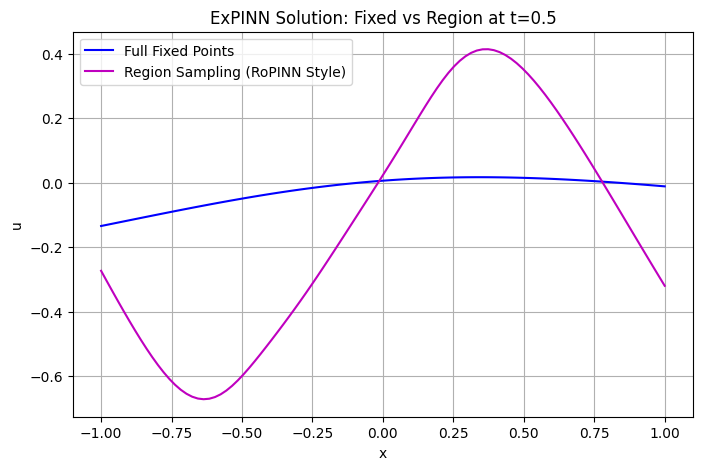


=== Region ExPINN Demo ===
Final Total Loss (Region): 0.18052592873573303
Enhanced Explanation: Peak at 0.671 driven by diffusion (advection=0.0096 < diffusion=0.1420) near x=-0.64.
--- Full Informed ML: Region Opt (RoPINN p.4) + Grad-Based Rules (EMNLP p.26) ---


In [ ]:
# Predict with region model at t=0.5
u_pred_region = model_region(xt_test_full).detach().numpy()

# Reuse enhanced_explanation from Cell 7 (or copy if needed)
region_explanation = generate_enhanced_explanation(model_region, xt_test_full, u_pred_region)

print("Sample u_pred_region:", u_pred_region.flatten()[:5])
print("Peak Velocity (Region):", np.max(np.abs(u_pred_region)))
print(region_explanation)

# Plot comparison (fixed vs region)
plt.figure(figsize=(8,5))
plt.plot(x_test.numpy(), u_pred_full, 'b-', label='Full Fixed Points')
plt.plot(x_test.numpy(), u_pred_region, 'm-', label='Region Sampling (RoPINN Style)')
plt.title('ExPINN Solution: Fixed vs Region at t=0.5')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Region ExPINN Demo ===")
print("Final Total Loss (Region):", losses_region['total'][-1])
print(region_explanation)
print("--- Full Informed ML: Region Opt (RoPINN p.4) + Grad-Based Rules (EMNLP p.26) ---")

In [ ]:
!pip install gradio -q  # Quiet install if needed

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

# Wrapper for prediction + explanation (use model_region)
def predict_and_explain(x_input, t_input):
    # Single point predict
    xt_single = torch.tensor([[float(x_input), float(t_input)]], dtype=torch.float32)
    u_single = model_region(xt_single).item()

    # Explanation (mock full batch for grad, use nearby points)
    x_near = torch.linspace(max(-1, x_input-0.1), min(1, x_input+0.1), 20).unsqueeze(1)
    t_near = torch.ones_like(x_near) * float(t_input)
    xt_near = torch.cat([x_near, t_near], dim=1)
    u_near = model_region(xt_near).detach().numpy()

    expl = generate_enhanced_explanation(model_region, xt_near, u_near, threshold=0.05)  # Lower threshold for demo

    # Mini plot around point
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(x_near.numpy(), u_near, 'b-', label='u(x, t)')
    ax.axvline(x=float(x_input), color='red', linestyle='--', label=f'Query x={x_input}')
    ax.set_title(f'u({x_input}, {t_input}) = {u_single:.3f}\n{expl}')
    ax.set_xlabel('x near query')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    return f"u({x_input}, {t_input}) = {u_single:.3f}", expl, fig

# Gradio interface
with gr.Blocks(title="ExPINN Interactive Demo") as demo:
    gr.Markdown("# ExPINN: Physics + Explanation Demo\nBased on RoPINN (NeurIPS 2024) + NLE (EMNLP 2024)")
    with gr.Row():
        x_slider = gr.Slider(-1, 1, value=0, label="x")
        t_slider = gr.Slider(0, 1, value=0.5, label="t")
    predict_btn = gr.Button("Predict & Explain")

    u_out = gr.Textbox(label="u(x,t)")
    expl_out = gr.Textbox(label="Natural Language Explanation")
    plot_out = gr.Plot(label="Local Solution Plot")

    predict_btn.click(predict_and_explain, inputs=[x_slider, t_slider], outputs=[u_out, expl_out, plot_out])

# Launch (public link for share)
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://437e49b9a2ee37f3fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
